# Customer Sentiment Analysis of Amazon Reviews Using NLTK and Transformer-Based NLP

## Section 1 - Import Libraries

In [43]:
!pip install pandas nltk transformers torch scikit-learn matplotlib seaborn tqdm

In [44]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.tokenize import sent_tokenize, word_tokenize
from transformers import pipeline
from tqdm.auto import tqdm

In [45]:
nltk.download("punkt")
nltk.download("punkt_tab")

## Section 2 - Load Dataset

In [46]:
df = pd.read_csv("../../../Datasets/Amazon Customer Review Data 60k/Amazon Review Data Web Scrapping - Amazon Review Data Web Scrapping.csv")

In [47]:
print(df.columns.tolist())

['Unique_ID', 'Category', 'Review_Header', 'Review_text', 'Rating', 'Own_Rating']


In [48]:
df.head()

,Unique_ID,Category,Review_Header,Review_text,Rating,Own_Rating
0,136040,smartTv,Nice one,I liked it,5,Positive
1,134236,mobile,Huge battery life with amazing display,I bought the phone on Amazon and been using my...,5,Positive
2,113945,books,Four Stars,"Awesome book at reasonable price, must buy ......",4,Positive
3,168076,smartTv,Nice quality,good,5,Positive
4,157302,books,Nice book,"The book is fine,not bad,contains nice concept...",3,Neutral


In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60889 entries, 0 to 60888
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Unique_ID      60889 non-null  int64
 1   Category       60889 non-null  str  
 2   Review_Header  60884 non-null  str  
 3   Review_text    60857 non-null  str  
 4   Rating         60889 non-null  int64
 5   Own_Rating     60889 non-null  str  
dtypes: int64(2), str(4)
memory usage: 2.8 MB


In [50]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 60889
Columns: 6


## Section 3 - Data Cleaning

In [51]:
df.isnull().sum()

Unique_ID         0
Category          0
Review_Header     5
Review_text      32
Rating            0
Own_Rating        0
dtype: int64

In [53]:
df = df.dropna(subset=["Review_text"])

In [54]:
df["Review_text"] = df["Review_text"].astype(str)

In [55]:
print(df["Review_text"].apply(type).value_counts())

Review_text
<class 'str'>    60857
Name: count, dtype: int64


In [56]:
print(df["Review_text"].iloc[0])

I liked it


In [57]:
print(df["Rating"].value_counts().sort_index())

Rating
1     6979
2     2107
3     4364
4    12968
5    34439
Name: count, dtype: int64


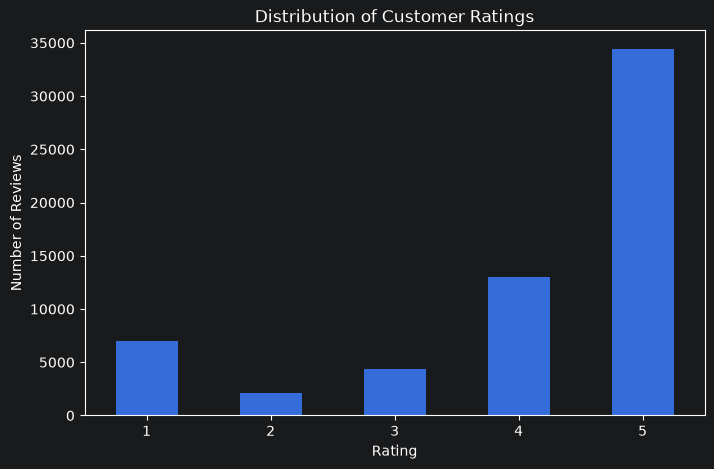

In [58]:
df["Rating"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

## Section 4 - Sentence Tokenization

In [60]:
review = df["Review_text"].iloc[0]

sentences = sent_tokenize(review)

print("Review:")
print(review)

print("\nNumber of sentences:", len(sentences))

for i, sentence in enumerate(sentences, 1):
    print(f"Sentence {i}: {sentence}")

Review:
I liked it

Number of sentences: 1
Sentence 1: I liked it


In [62]:
df["Sentences"] = df["Review_text"].apply(sent_tokenize)

In [64]:
df[["Review_text", "Sentences"]].head()

,Review_text,Sentences
0,I liked it,[I liked it]
1,I bought the phone on Amazon and been using my...,[I bought the phone on Amazon and been using m...
2,"Awesome book at reasonable price, must buy ......","[Awesome book at reasonable price, must buy ....."
3,good,[good]
4,"The book is fine,not bad,contains nice concept...","[The book is fine,not bad,contains nice concep..."


## Section 5 - Word Tokenization

In [65]:
def tokenize_words(sentences):
    return [
        word_tokenize(sentence)
        for sentence in sentences
    ]

In [66]:
df["Word_Tokens"] = df["Sentences"].apply(tokenize_words)

In [67]:
df[["Sentences", "Word_Tokens"]].head()

,Sentences,Word_Tokens
0,[I liked it],"[[I, liked, it]]"
1,[I bought the phone on Amazon and been using m...,"[[I, bought, the, phone, on, Amazon, and, been..."
2,"[Awesome book at reasonable price, must buy .....","[[Awesome, book, at, reasonable, price, ,, mus..."
3,[good],[[good]]
4,"[The book is fine,not bad,contains nice concep...","[[The, book, is, fine, ,, not, bad, ,, contain..."


## Section 6 - Count Number of Sentences

In [68]:
df["Sentence_Count"] = df["Sentences"].apply(len)

In [70]:
df[["Review_text", "Sentence_Count"]].head(10)

,Review_text,Sentence_Count
0,I liked it,1
1,I bought the phone on Amazon and been using my...,24
2,"Awesome book at reasonable price, must buy ......",1
3,good,1
4,"The book is fine,not bad,contains nice concept...",2
5,Nice tv and pic quality .good custmer srrvice ...,1
6,The iPhone 7 is legitimately among the most in...,4
7,"20000 mAH, what more you need. Super product",2
8,The company should give more Bettany backup an...,1
9,Very good phone,1


In [71]:
print(
    "Average number of sentences:",
    df["Sentence_Count"].mean()
)

Average number of sentences: 2.3289350444484613


## Section 7 - Count Words in Each Sentence

In [72]:
def count_words_per_sentence(word_tokens):
    return [
        len(sentence_words)
        for sentence_words in word_tokens
    ]

In [73]:
df["Words_Per_Sentence"] = df["Word_Tokens"].apply(
    count_words_per_sentence
)

In [75]:
df[
    [
        "Review_text",
        "Sentence_Count",
        "Words_Per_Sentence"
    ]
].head(10)

,Review_text,Sentence_Count,Words_Per_Sentence
0,I liked it,1,[3]
1,I bought the phone on Amazon and been using my...,24,"[18, 8, 11, 10, 16, 11, 9, 8, 11, 16, 9, 13, 7..."
2,"Awesome book at reasonable price, must buy ......",1,[9]
3,good,1,[1]
4,"The book is fine,not bad,contains nice concept...",2,"[15, 4]"
5,Nice tv and pic quality .good custmer srrvice ...,1,[18]
6,The iPhone 7 is legitimately among the most in...,4,"[34, 48, 45, 13]"
7,"20000 mAH, what more you need. Super product",2,"[8, 2]"
8,The company should give more Bettany backup an...,1,[10]
9,Very good phone,1,[3]


## Section 8 - Flag Reviews With More Than 3 Sentences

In [76]:
df["Flag_For_Analysis"] = df["Sentence_Count"] > 3

In [77]:
print(
    df["Flag_For_Analysis"].value_counts()
)

Flag_For_Analysis
False    51279
True      9578
Name: count, dtype: int64


In [79]:
flagged_reviews = df[
    df["Flag_For_Analysis"] == True
]

flagged_reviews[
    [
        "Review_text",
        "Sentence_Count"
    ]
].head(10)

,Review_text,Sentence_Count
1,I bought the phone on Amazon and been using my...,24
6,The iPhone 7 is legitimately among the most in...,4
16,I’m a fan of Alexa Fire Stick. Its a value for...,5
22,Good product in this range. Everything is good...,4
26,Best ever phone I have used.. Gorgeous speed.....,4
31,Worst product!!!! Just becz of rain i got wate...,7
33,Phone is ok... But there are lot of problems s...,7
44,This is a very good mobile under 15K. Both Sel...,5
46,Rear camera is average. Battery last full day....,4
47,Realme U1 is really an awesome product.This is...,4


In [80]:
percentage_flagged = (
    df["Flag_For_Analysis"].mean() * 100
)

print(
    f"Reviews with more than 3 sentences: "
    f"{percentage_flagged:.2f}%"
)

Reviews with more than 3 sentences: 15.74%


## Section 9 - Create the Transformer Sentiment Analyzer

In [81]:
sentiment_analyzer = pipeline(
    "sentiment-analysis"
)

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 12850.80it/s]


In [82]:
test_review = (
    "The product quality is excellent. "
    "I am very satisfied with the purchase."
)

result = sentiment_analyzer(test_review)

print(result)

[{'label': 'POSITIVE', 'score': 0.9998704195022583}]


## Section 10 - Test Negative Sentiment

In [83]:
test_review = (
    "Terrible customer service. "
    "I waited two weeks for a response."
)

result = sentiment_analyzer(test_review)

print(result)

[{'label': 'NEGATIVE', 'score': 0.9996765851974487}]


## Section 11 - Run Sentiment Analysis on the Dataset

In [84]:
reviews = df["Review_text"].tolist()

results = []

for i in tqdm(
    range(0, len(reviews), 32)
):

    batch = reviews[i:i+32]

    batch_results = sentiment_analyzer(
        batch,
        batch_size=32,
        truncation=True
    )

    results.extend(batch_results)

100%|██████████| 1902/1902 [08:01<00:00,  3.95it/s]


## Section 12 - Add Sentiment to DataFrame

In [85]:
df["Sentiment"] = [
    result["label"]
    for result in results
]

df["Sentiment_Score"] = [
    result["score"]
    for result in results
]

In [87]:
df[
    [
        "Review_text",
        "Rating",
        "Sentiment",
        "Sentiment_Score"
    ]
].head(10)

,Review_text,Rating,Sentiment,Sentiment_Score
0,I liked it,5,POSITIVE,0.999826
1,I bought the phone on Amazon and been using my...,5,NEGATIVE,0.857909
2,"Awesome book at reasonable price, must buy ......",4,POSITIVE,0.999612
3,good,5,POSITIVE,0.999816
4,"The book is fine,not bad,contains nice concept...",3,POSITIVE,0.999845
5,Nice tv and pic quality .good custmer srrvice ...,5,POSITIVE,0.992494
6,The iPhone 7 is legitimately among the most in...,5,NEGATIVE,0.938811
7,"20000 mAH, what more you need. Super product",5,NEGATIVE,0.809809
8,The company should give more Bettany backup an...,2,NEGATIVE,0.995394
9,Very good phone,5,POSITIVE,0.999864


## Section 13 - Sentiment Distribution

In [88]:
print(df["Sentiment"].value_counts())

Sentiment
POSITIVE    40749
NEGATIVE    20108
Name: count, dtype: int64


In [89]:
sentiment_percentage = (
    df["Sentiment"]
    .value_counts(normalize=True)
    * 100
)

print(sentiment_percentage)

Sentiment
POSITIVE    66.958608
NEGATIVE    33.041392
Name: proportion, dtype: float64


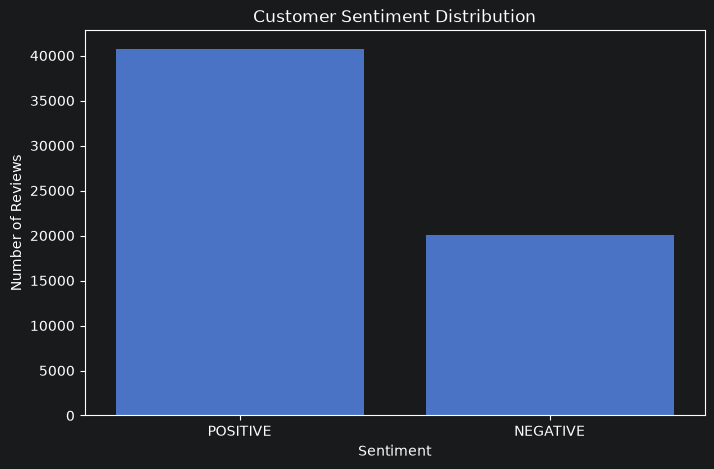

In [90]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment"
)

plt.title("Customer Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

## Section 14 - Compare Rating With Sentiment

In [91]:
rating_sentiment_table = pd.crosstab(
    df["Rating"],
    df["Sentiment"]
)

print(rating_sentiment_table)

Sentiment  NEGATIVE  POSITIVE
Rating                       
1              6638       341
2              1885       222
3              2896      1468
4              3945      9023
5              4744     29695


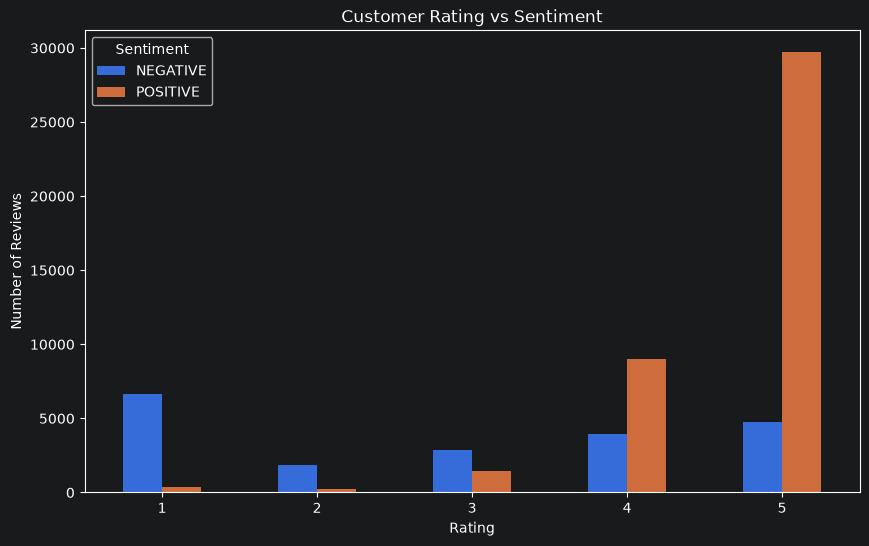

In [92]:
rating_sentiment_table.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Customer Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

## Section 15 - Convert Rating Into Sentiment
- 1–2 → Negative
- 3   → Neutral
- 4–5 → Positive

In [93]:
def rating_to_sentiment(rating):

    if rating <= 2:
        return "NEGATIVE"

    elif rating == 3:
        return "NEUTRAL"

    else:
        return "POSITIVE"

In [94]:
df["Rating_Sentiment"] = df["Rating"].apply(
    rating_to_sentiment
)

In [95]:
df[
    [
        "Rating",
        "Rating_Sentiment"
    ]
].head()

,Rating,Rating_Sentiment
0,5,POSITIVE
1,5,POSITIVE
2,4,POSITIVE
3,5,POSITIVE
4,3,NEUTRAL


## Section 16 - Compare Model Sentiment vs Rating

In [96]:
comparison = pd.crosstab(
    df["Rating_Sentiment"],
    df["Sentiment"]
)

print(comparison)

Sentiment         NEGATIVE  POSITIVE
Rating_Sentiment                    
NEGATIVE              8523       563
NEUTRAL               2896      1468
POSITIVE              8689     38718


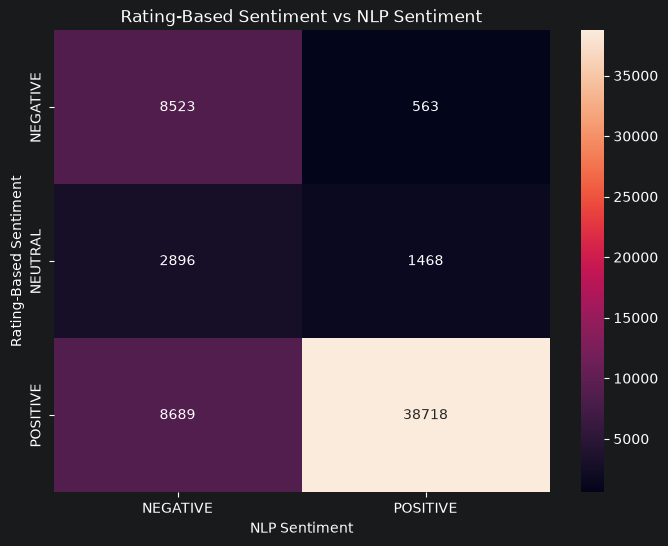

In [97]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    comparison,
    annot=True,
    fmt="d"
)

plt.title(
    "Rating-Based Sentiment vs NLP Sentiment"
)

plt.xlabel("NLP Sentiment")
plt.ylabel("Rating-Based Sentiment")

plt.show()

## Section 17 - Calculate Agreement

In [98]:
agreement = (
    df["Rating_Sentiment"] ==
    df["Sentiment"]
).mean()

print(
    f"Sentiment agreement: {agreement:.2%}"
)

Sentiment agreement: 77.63%


## Section 18 - Find Rating/Sentiment Mismatches

In [99]:
positive_rating_negative_text = df[
    (df["Rating"] >= 4) &
    (df["Sentiment"] == "NEGATIVE")
]

positive_rating_negative_text[
    [
        "Rating",
        "Sentiment",
        "Sentiment_Score",
        "Review_text"
    ]
].head(10)

,Rating,Sentiment,Sentiment_Score,Review_text
1,5,NEGATIVE,0.857909,I bought the phone on Amazon and been using my...
6,5,NEGATIVE,0.938811,The iPhone 7 is legitimately among the most in...
7,5,NEGATIVE,0.809809,"20000 mAH, what more you need. Super product"
38,4,NEGATIVE,0.768131,"The phone really works great, The best thing a..."
45,5,NEGATIVE,0.971639,Ausam product.... Go for it....
46,4,NEGATIVE,0.984790,Rear camera is average. Battery last full day....
48,5,NEGATIVE,0.971635,Normal use mai battery 3.5 hours nikal deti ha...
58,5,NEGATIVE,0.978520,Only battery
66,4,NEGATIVE,0.995160,This phone is complete package of low cost
67,5,NEGATIVE,0.708141,First of all I would like to say about the del...


In [100]:
negative_rating_positive_text = df[
    (df["Rating"] <= 2) &
    (df["Sentiment"] == "POSITIVE")
]

negative_rating_positive_text[
    [
        "Rating",
        "Sentiment",
        "Sentiment_Score",
        "Review_text"
    ]
].head(10)

,Rating,Sentiment,Sentiment_Score,Review_text
69,2,POSITIVE,0.999785,Ok
166,1,POSITIVE,0.996785,Main Problem is when we make a call there is a...
354,2,POSITIVE,0.999855,Nice
493,2,POSITIVE,0.999534,"Over all phone quality is good, except camera ..."
504,2,POSITIVE,0.999655,Totally Chinese
678,1,POSITIVE,0.994724,box m lightning conductor nhi aaya
723,1,POSITIVE,0.999621,Nice phone
724,1,POSITIVE,0.999859,Good product
912,1,POSITIVE,0.950993,Camera is good... I but product getting high t...
1011,1,POSITIVE,0.910621,Broke within a week.


## Section 19 - Analyze Sentiment Confidence

In [101]:
print(
    df["Sentiment_Score"].describe()
)

count    60857.000000
mean         0.979788
std          0.066494
min          0.500011
25%          0.995467
50%          0.999487
75%          0.999816
max          0.999892
Name: Sentiment_Score, dtype: float64


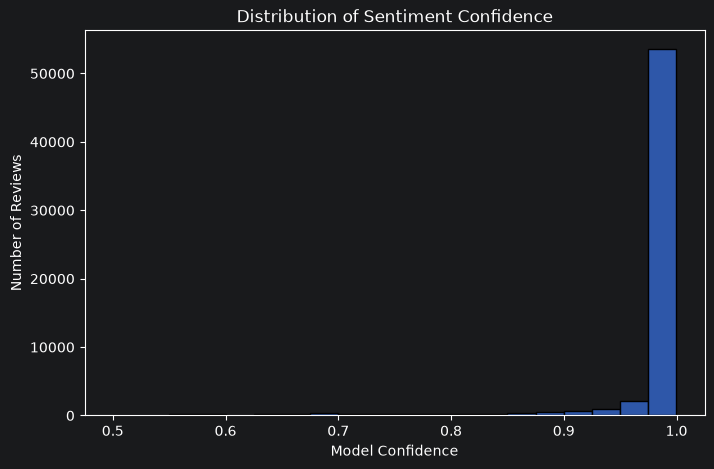

In [102]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Sentiment_Score",
    bins=20
)

plt.title("Distribution of Sentiment Confidence")
plt.xlabel("Model Confidence")
plt.ylabel("Number of Reviews")

plt.show()

## Section 20 - Average Confidence by Sentiment

In [103]:
df.groupby("Sentiment")[
    "Sentiment_Score"
].mean()

Sentiment
NEGATIVE    0.968182
POSITIVE    0.985516
Name: Sentiment_Score, dtype: float64

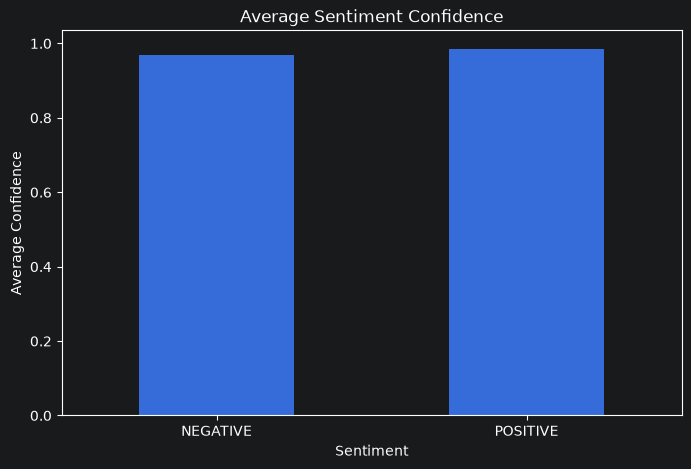

In [104]:
df.groupby("Sentiment")[
    "Sentiment_Score"
].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Sentiment Confidence")
plt.xlabel("Sentiment")
plt.ylabel("Average Confidence")

plt.xticks(rotation=0)
plt.show()

## Section 21 - Analyze Long Reviews

In [105]:
print(
    "Total reviews:",
    len(df)
)

print(
    "Reviews with >3 sentences:",
    df["Flag_For_Analysis"].sum()
)

Total reviews: 60857
Reviews with >3 sentences: 9578


In [106]:
long_review_sentiment = pd.crosstab(
    df["Flag_For_Analysis"],
    df["Sentiment"]
)

print(long_review_sentiment)

Sentiment          NEGATIVE  POSITIVE
Flag_For_Analysis                    
False                 16139     35140
True                   3969      5609


## Section 22 - Average Review Length by Sentiment

In [107]:
df.groupby("Sentiment")[
    "Sentence_Count"
].mean()

Sentiment
NEGATIVE    2.687388
POSITIVE    2.152053
Name: Sentence_Count, dtype: float64

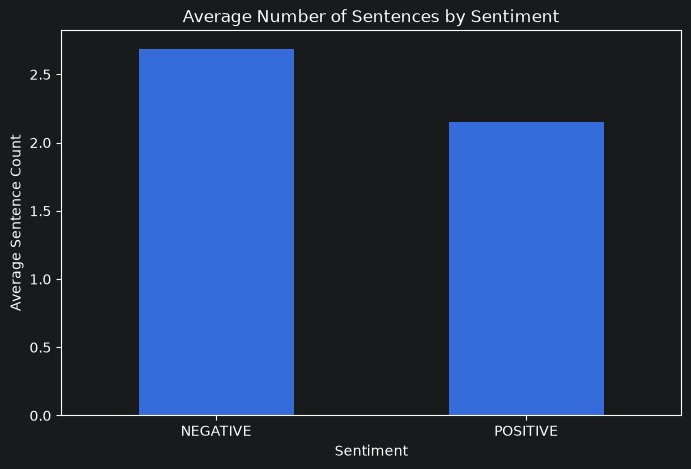

In [108]:
df.groupby("Sentiment")[
    "Sentence_Count"
].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title(
    "Average Number of Sentences by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Average Sentence Count")

plt.xticks(rotation=0)
plt.show()

## Section 23 - Save Results

In [109]:
df.to_csv(
    "amazon_sentiment_analysis_results.csv",
    index=False
)